## MD RAIHANUL ISLAM BHUIYAN
Exploratory Data Analysis (EDA) on the Titanic Dataset using pandas, matplotlib and seaborn.

In [1]:
#Importing the required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Loadind the dataset from local machine
pd.read_csv(r"D:\Ostad\Class materials\titanic_data.csv")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
#Loading the dataset from online source
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv")

In [4]:
#Checking the first 5 rows of the dataset
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
#Check the data types of all columns 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
#Descriptive statistics of the numerical columns
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
#Percentage of missing values in the 'Cabin' column

missing_pct = df['Cabin'].isna().mean() * 100
print(f"Missing Cabin values: {missing_pct}%")

Missing Cabin values: 77.10437710437711%


## Dropping the Cabin Column

The `Cabin` column has a high percentage of missing values (77.1%), which can lead to biased or unreliable results if it is included in the analysis. Dropping it keeps the analysis reliable.

In [9]:
# Impute missing values and find out the most frequent value in the 'Embarked' column
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
print (f"Most frequent value: {df["Embarked"].mode()[0]}")

Most frequent value: S


In [10]:
df["Embarked"]

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: str

In [11]:
#Fill missing values in the 'Age' column with the mean of the column
df["Age"] = df["Age"].fillna(df["Age"].mean())
print(df["Age"])


0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64


In [12]:
# Calculate the overall survival rate
survival_rate = df["Survived"].mean() * 100
print(survival_rate)

38.38383838383838


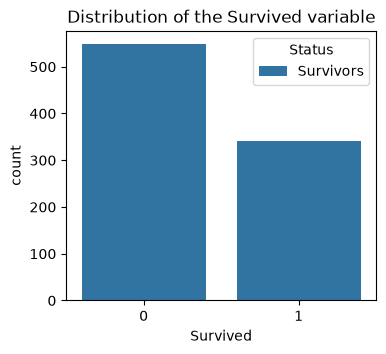

In [13]:

#Survived variable distribution
fig, ax = plt.subplots(figsize=(4, 3.5))
sns.countplot(data=df[df["Survived"].notnull()], x="Survived", ax=ax)
ax.set_title("Distribution of the Survived variable")
ax.legend(labels=["Survivors", "Non-Survivors"], title="Status")

Text(0.5, 1.0, 'Distribution of the Pclass variable')

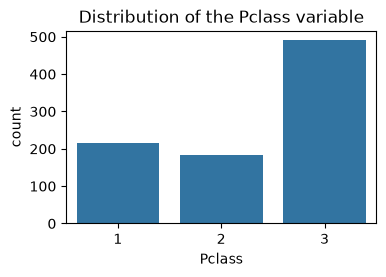

In [14]:
#Pclass variable distribution
fig, ax = plt.subplots(figsize=(4, 2.5))
sns.countplot(data=df, x="Pclass", ax=ax)
ax.set_title("Distribution of the Pclass variable")

Class 3 has the most passenger

Text(0.5, 1.0, 'Distribution of the Age variable')

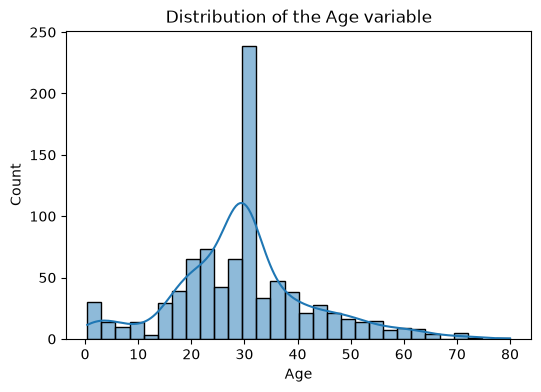

In [15]:
#Age variable distribution
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(data=df, x="Age", bins=30, kde=True, ax=ax)
ax.set_title("Distribution of the Age variable")

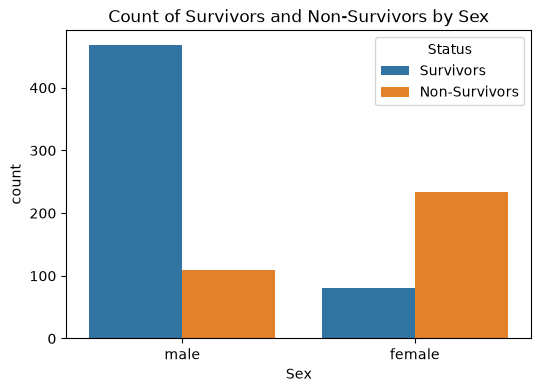

In [16]:
#Count of survivores and non survivors by Sexual orientation
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="Sex", hue="Survived", ax=ax)
ax.set_title("Count of Survivors and Non-Survivors by Sex")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=["Survivors", "Non-Survivors"], title="Status")

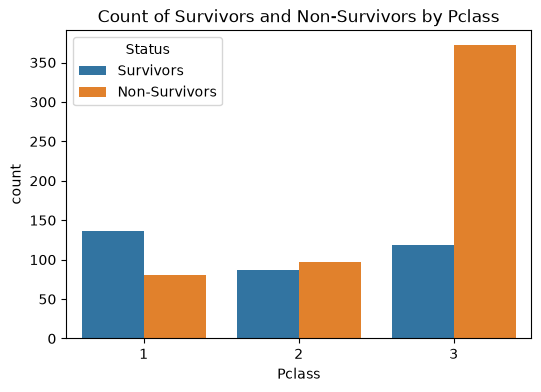

In [17]:
#Survived by Pclass
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="Pclass", hue="Survived", hue_order = (1,0), ax=ax)
ax.set_title("Count of Survivors and Non-Survivors by Pclass")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=["Survivors", "Non-Survivors"], title="Status")

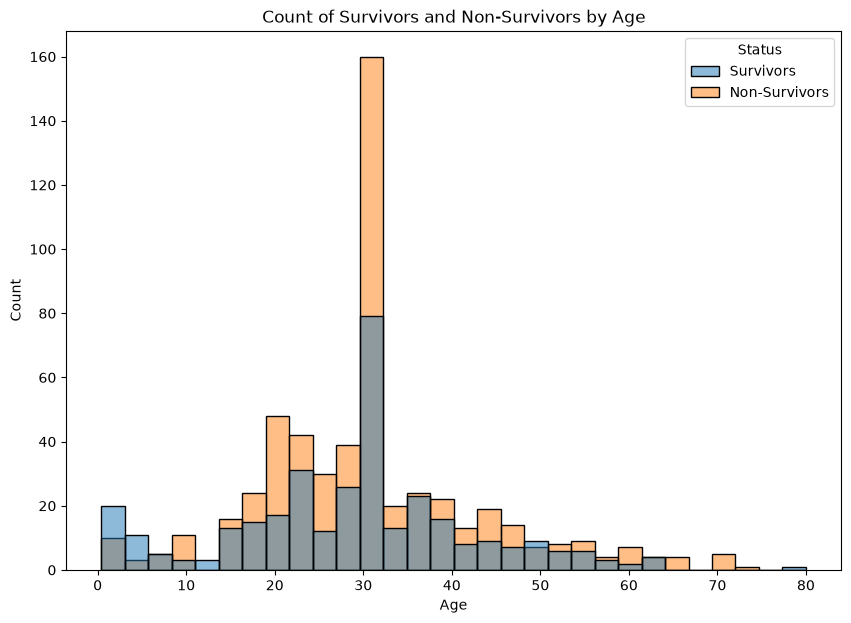

In [18]:
# Survived by Age
fig, ax = plt.subplots(figsize=(10, 7))
sns.histplot(data=df, x="Age", hue="Survived", hue_order=[1, 0], ax=ax)
ax.set_title("Count of Survivors and Non-Survivors by Age")
sns.move_legend(ax, "upper right", labels=["Survivors", "Non-Survivors"], title="Status")

Children <10 years Highest survival rates, driven by evacuation priority.
Adults between 20-40 years represent the bulk of fatalities due to sheer volume onboard.
Elderly >60 years Lowest survival rates, facing the highest risk of mortality.

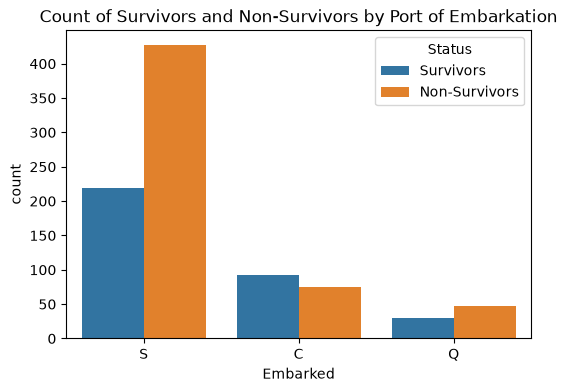

In [19]:
#Survival by Port of Embarkation (Embarked)
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="Embarked", hue="Survived", hue_order=[1, 0], ax=ax)
ax.set_title("Count of Survivors and Non-Survivors by Port of Embarkation")
sns.move_legend(ax, "upper right", labels=["Survivors", "Non-Survivors"], title="Status")

Text(0, 0.5, 'Survival Rate (%)')

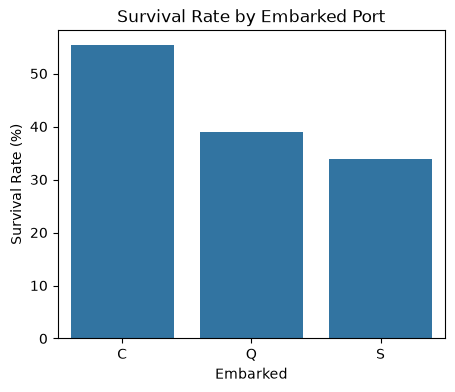

In [20]:
# Calculate survival rates (%)
rates = df.groupby("Embarked")["Survived"].mean().reset_index()
rates["Survived"] *= 100
fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(data=rates, x="Embarked", y="Survived", ax=ax)
ax.set_title("Survival Rate by Embarked Port")
ax.set_ylabel("Survival Rate (%)")


# Titanic Dataset: Exploratory Data Analysis Findings

## 1. Survival Overview
- The number of passengers who did **not survive** is greater than the number who **survived**.

## 2. Passenger Demographics

### Passenger Class
- Class 3 had the most passengers, followed by Class 1, then Class 2 (**3 > 1 > 2**).

### Age Distribution
- Most passengers were around **30 years old**.
- There were more children than elderly passengers; the number of elderly passengers was very low.

### Port of Embarkation
- Most passengers boarded at **Southampton**.

## 3. Survival Analysis

### By Gender
- **Female** passengers had a higher survival count than male passengers.
- Most **male** passengers did not survive.

### By Passenger Class
- Most non-survivors were from **Class 3**.

### By Age Group
| Age Group | Survival Outcome |
|---|---|
| Children (< 10 years) | Highest survival rate, likely due to evacuation priority |
| Adults (20–40 years) | Largest share of fatalities, simply because they were the largest group onboard |
| Elderly (> 60 years) | Lowest survival rate, highest risk of mortality |

### By Port of Embarkation
- Most non-survivors boarded at **Southampton**.
- **Cherbourg** had the highest survival rate; **Southampton** had the lowest.

## Key Takeaways
- Survival was strongly linked to **gender, passenger class, and age**.
- Class 3 passengers, men, and the elderly were at the greatest risk.
- Children and women had the best chances of survival.